# Oráculo: filtrado de clutter en staggered-PRT (Sachidananda & Zrnić 2000)

Oráculo de [`docs/algorithms/staggered-prt.md`](../../docs/algorithms/staggered-prt.md)
§"El problema del clutter", derivado del paper, independiente de cualquier
código Rust (primer paso del método de `docs/algorithms/roadmap.md`
§"Método de estudio"). Hasta ahora la página autorizaba explícitamente
diferir este filtro en Stage 1 (`crates/staggered-prt` sólo estima
velocidad); este oráculo cierra ese hueco.

**La idea del paper.** Con muestreo uniforme el clutter cae en 0 Hz y un
notch en frecuencia lo separa de la señal meteorológica sin más. Con
muestreo escalonado `T1, T2, T1, T2, …` no hay una FFT ordinaria: el
espectro de una serie no uniformemente muestreada tiene réplicas que
ensucian toda la banda, y un notch ingenuo sobre esa serie destruye señal
que no debería tocar. Sachidananda & Zrnić (2000) resuelven esto separando
la serie escalonada en las **dos subsecuencias uniformes que la componen**:
los pulsos de índice par (tiempos `0, Ts, 2·Ts, …`) y los de índice impar
(tiempos `T1, T1+Ts, T1+2·Ts, …`), con `Ts = T1+T2`. Cada subsecuencia por
separado **sí** está uniformemente muestreada a periodo `Ts`, así que el
clutter —estacionario por definición— cae exactamente en 0 Hz de *cada*
subsecuencia, se filtra ahí con un notch ordinario, y las dos subsecuencias
filtradas se entrelazan de vuelta para reconstruir la serie escalonada.
Sobre la serie reconstruida se aplica el mismo estimador pulse-pair de
`crates/staggered-prt` sin cambio alguno (`R(T1)` de los pares
par-impar, `R(T2)` de los impar-par).

**Alcance de Stage 1, declarado.** La página de
[GMAP](gmap-clutter-filtering.md) muestra que un notch destruye la señal
meteorológica cuando su velocidad verdadera cae dentro de la banda de
clutter, y que la reconstrucción gaussiana (GMAP) es la respuesta a eso.
Adaptar GMAP a dos subsecuencias que hay que mantener consistentes entre sí
antes de entrelazarlas es trabajo adicional no trivial que esta página no
exige para Stage 1 —el propio doc califica el filtrado escalonado como «el
trabajo más pesado de esta técnica»—. Este oráculo valida **notch puro**
sobre las dos subsecuencias: es la pieza mínima que el paper describe
(descomponer, filtrar, reconstruir) y ya es una mejora real respecto a no
tener filtro alguno. La limitación heredada del notch —pérdida de señal
cuando la velocidad verdadera cae en la banda de clutter de la
subsecuencia— se mide y se declara explícitamente en la Prueba 3, no se
oculta.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(20260913)
plt.rcParams["figure.figsize"] = (9, 4)
np.set_printoptions(precision=4, suppress=True)


## Generador: mismo modelo de Cholesky del oráculo de staggered-PRT, con clutter añadido

Igual que en `staggered_prt.ipynb`: matriz de covarianza `C[i,j] = R(t_i - t_j)`
evaluada en los tiempos de muestreo reales (no uniformes), con la ACF
gaussiana cerrada de Doviak & Zrnić. El clutter se añade como una segunda
componente de la misma forma funcional, con velocidad media cero y ancho
espectral casi nulo (`sigma_v` muy pequeño → decorrelación despreciable en
los retardos del burst → potencia prácticamente constante en el tiempo,
blanco estacionario), exactamente el mismo modelo de "blanco fijo en
tierra" que usa `gmap_clutter_filtering.ipynb`, sólo que aquí en el dominio
del tiempo en vez del espectral porque el muestreo no es uniforme.

In [2]:
def analytic_acf(power_s, mean_v, sigma_v, wavelength_m, tau):
    """R(tau) cerrada de Doviak & Zrnic (1993) cap. 6, evaluada en retardos
    arbitrarios (no sólo múltiplos de un PRT uniforme) -- misma que en
    staggered_prt.ipynb."""
    phase = np.exp(1j * 4.0 * np.pi * mean_v * tau / wavelength_m)
    decay = np.exp(-8.0 * np.pi ** 2 * sigma_v ** 2 * tau ** 2 / wavelength_m ** 2)
    return power_s * phase * decay


def staggered_times(m, t1, t2):
    dt = np.array([t1 if i % 2 == 0 else t2 for i in range(m - 1)])
    return np.concatenate([[0.0], np.cumsum(dt)])


def generate_staggered_cell_with_clutter(power_weather, mean_v, sigma_v, power_clutter,
                                          wavelength_m, t1, t2, m, noise_floor, rng,
                                          clutter_sigma_v=1.0e-3):
    times = staggered_times(m, t1, t2)
    tau = times[:, None] - times[None, :]
    C = analytic_acf(power_weather, mean_v, sigma_v, wavelength_m, tau)
    if power_clutter > 0.0:
        C = C + analytic_acf(power_clutter, 0.0, clutter_sigma_v, wavelength_m, tau)
    C = (C + C.conj().T) / 2.0  # hermitizar (redondeo de punto flotante)
    L = np.linalg.cholesky(C + 1e-9 * (power_weather + power_clutter) * np.eye(m))
    z = (rng.normal(0.0, 1.0, m) + 1j * rng.normal(0.0, 1.0, m)) / np.sqrt(2.0)
    x = L @ z
    if noise_floor > 0.0:
        x = x + (rng.normal(0.0, np.sqrt(noise_floor / 2.0), m)
                  + 1j * rng.normal(0.0, np.sqrt(noise_floor / 2.0), m))
    return x


checks = []


## Descomposición, notch por subsecuencia, reconstrucción

`split_subsequences` separa la ráfaga en las dos subsecuencias uniformes de
periodo `Ts = T1+T2` (par: empieza en `t=0`; impar: empieza en `t=T1`).
`notch_subsequence` aplica FFT ordinaria, estima el ruido con Hildebrand &
Sekhon (1974) *antes* de filtrar (igual que `gmap_clutter_filtering.ipynb`,
para no sesgar la resta de ruido con el propio filtro), pone a cero los
bins dentro de la banda de clutter alrededor de 0 Hz, y vuelve al dominio
del tiempo. `sz2000_filter` aplica esto a las dos subsecuencias y entrelaza
el resultado de vuelta al orden original.

In [3]:
def periodogram_raw(y):
    m = len(y)
    yf = np.fft.fft(y)
    return (np.abs(yf) ** 2) / (m ** 2)


def hildebrand_sekhon(p, navg=1):
    p_sorted = np.sort(p)
    n = len(p_sorted)
    rtest = 1.0 + 1.0 / navg
    nnoise = n
    sum1 = 0.0
    sum2 = 0.0
    for i in range(n):
        pwr = p_sorted[i]
        npts = i + 1
        sum1 += pwr
        sum2 += pwr * pwr
        if npts * sum2 < sum1 * sum1 * rtest:
            nnoise = npts
        else:
            sum1 -= pwr
            sum2 -= pwr * pwr
            break
    return sum1 / nnoise


def noise_floor_estimate(y):
    return hildebrand_sekhon(periodogram_raw(y)) * len(y)


def split_subsequences(x):
    return x[0::2], x[1::2]


def notch_subsequence(sub, half_width_bins):
    m = len(sub)
    n_hat = noise_floor_estimate(sub)
    X = np.fft.fft(sub)
    mask = np.zeros(m, dtype=bool)
    mask[: half_width_bins + 1] = True
    mask[m - half_width_bins :] = True
    X_filtered = X.copy()
    X_filtered[mask] = 0.0
    sub_filtered = np.fft.ifft(X_filtered)
    return sub_filtered, n_hat


def sz2000_filter(x, half_width_bins):
    a, b = split_subsequences(x)
    a_f, n_a = notch_subsequence(a, half_width_bins)
    b_f, n_b = notch_subsequence(b, half_width_bins)
    z_f = np.empty_like(x)
    z_f[0::2] = a_f
    z_f[1::2] = b_f
    return z_f, a_f, b_f, n_a, n_b


def staggered_pulse_pair(x, wavelength_m, t1, t2):
    r1 = np.mean(x[0:-1:2] * np.conj(x[1::2]))
    r2 = np.mean(x[1:-1:2] * np.conj(x[2::2]))
    v1 = -wavelength_m / (4.0 * np.pi * t1) * np.angle(r1)
    v2 = -wavelength_m / (4.0 * np.pi * t2) * np.angle(r2)
    return v1, v2


def reflectivity_estimate(a_f, b_f, n_a, n_b):
    s_a = max(np.mean(np.abs(a_f) ** 2) - n_a, 0.0)
    s_b = max(np.mean(np.abs(b_f) ** 2) - n_b, 0.0)
    return 0.5 * (s_a + s_b)


## Parámetros del escenario

Mismos `T1`, `T2` (razón 2:3) que `staggered_prt.ipynb`. `Ts = T1+T2` fija
la Nyquist de cada subsecuencia, `V_A_SUB` mucho menor que `V_A1`/`V_A2` —es
la banda donde el clutter de cada subsecuencia vive—. `HALF_WIDTH_BINS=2`
da un ancho de banda de notch comparable en bins al de
`gmap_clutter_filtering.ipynb`. La velocidad de prueba «segura»,
`V_SAFE_MPS = 8.0`, se elige —igual que en el oráculo de GMAP— lejos de la
banda de clutter *también dentro de cada subsecuencia* (no sólo lejos del
borde de desdoblado): a `8.0` m/s cae a más de 10 bins del centro de la
banda de notch, muy por fuera del `HALF_WIDTH_BINS=2`.

In [4]:
WAVELENGTH_M = 0.10
T1, T2 = 0.8e-3, 1.2e-3  # razon 2:3, igual que staggered_prt.ipynb
TS = T1 + T2
M = 64  # pulsos totales -> subsecuencias de 32
HALF_WIDTH_BINS = 2

V_A1 = WAVELENGTH_M / (4.0 * T1)
V_A2 = WAVELENGTH_M / (4.0 * T2)
V_A_SUB = WAVELENGTH_M / (4.0 * TS)
BIN_SPACING_SUB = 2.0 * V_A_SUB / (M // 2)
CLUTTER_BAND_MPS = HALF_WIDTH_BINS * BIN_SPACING_SUB

POWER_WEATHER = 1.0
NOISE_FLOOR = 0.05
SIGMA_V_TEST = 1.5
V_SAFE_MPS = 8.0

print(f"v_a1={V_A1:.3f} v_a2={V_A2:.3f} v_a_sub={V_A_SUB:.3f} m/s")
print(f"bin_spacing_sub={BIN_SPACING_SUB:.4f} m/s  banda de notch=+-{CLUTTER_BAND_MPS:.3f} m/s")
print(f"V_SAFE_MPS={V_SAFE_MPS} esta a {V_SAFE_MPS / BIN_SPACING_SUB:.1f} bins del centro de la banda")


v_a1=31.250 v_a2=20.833 v_a_sub=12.500 m/s
bin_spacing_sub=0.7812 m/s  banda de notch=+-1.562 m/s
V_SAFE_MPS=8.0 esta a 10.2 bins del centro de la banda


## Prueba 1 — caso que justifica el filtro: clutter fuerte, meteoro lejos de la banda

Clutter 20 dB más fuerte que la señal, velocidad verdadera `V_SAFE_MPS`
lejos de la banda de notch de ambas subsecuencias. Sin filtrar, el clutter
se cuela en `R(T1)`/`R(T2)` y sesga tanto potencia como velocidad. Filtrado
con SZ2000-notch, ambos deben recuperar la verdad-terreno dentro de un
margen comparable al caso sin clutter.

In [5]:
POWER_CLUTTER_STRONG = 100.0  # 20 dB sobre la senal
N_TRIALS_HEADLINE = 300


def run_trial(power_clutter, mean_v, sigma_v, apply_filter):
    x = generate_staggered_cell_with_clutter(POWER_WEATHER, mean_v, sigma_v, power_clutter,
                                              WAVELENGTH_M, T1, T2, M, NOISE_FLOOR, rng)
    if apply_filter:
        _, a_f, b_f, n_a, n_b = sz2000_filter(x, HALF_WIDTH_BINS)
        v1, v2 = staggered_pulse_pair(_reinterleave(a_f, b_f), WAVELENGTH_M, T1, T2)
        z_hat = reflectivity_estimate(a_f, b_f, n_a, n_b)
    else:
        v1, v2 = staggered_pulse_pair(x, WAVELENGTH_M, T1, T2)
        a, b = split_subsequences(x)
        n_a, n_b = noise_floor_estimate(a), noise_floor_estimate(b)
        z_hat = reflectivity_estimate(a, b, n_a, n_b)
    return v1, v2, z_hat


def _reinterleave(a_f, b_f):
    z = np.empty(len(a_f) + len(b_f), dtype=complex)
    z[0::2] = a_f
    z[1::2] = b_f
    return z


def summarize(power_clutter, mean_v, sigma_v, apply_filter, n_trials=N_TRIALS_HEADLINE):
    v1s, v2s, zs = [], [], []
    for _ in range(n_trials):
        v1, v2, z_hat = run_trial(power_clutter, mean_v, sigma_v, apply_filter)
        v1s.append(v1); v2s.append(v2); zs.append(z_hat)
    return np.mean(v1s), np.mean(v2s), np.mean(zs)


v1_clean, v2_clean, z_clean = summarize(0.0, V_SAFE_MPS, SIGMA_V_TEST, apply_filter=False)
v1_raw, v2_raw, z_raw = summarize(POWER_CLUTTER_STRONG, V_SAFE_MPS, SIGMA_V_TEST, apply_filter=False)
v1_filt, v2_filt, z_filt = summarize(POWER_CLUTTER_STRONG, V_SAFE_MPS, SIGMA_V_TEST, apply_filter=True)

print(f"verdad-terreno: v1=v2={V_SAFE_MPS} Z={POWER_WEATHER}")
print(f"sin clutter, sin filtro:  v1={v1_clean:+.3f} v2={v2_clean:+.3f} Z={z_clean:.4f}")
print(f"con clutter, sin filtro:  v1={v1_raw:+.3f} v2={v2_raw:+.3f} Z={z_raw:.4f}")
print(f"con clutter, con filtro:  v1={v1_filt:+.3f} v2={v2_filt:+.3f} Z={z_filt:.4f}")

checks.append(("sin filtrar, el clutter sesga Z en mas del 50% (justifica el filtro)",
               abs(z_raw - POWER_WEATHER) > 0.50 * POWER_WEATHER))
checks.append(("filtrado SZ2000-notch recupera Z dentro del 25% de la verdad-terreno",
               abs(z_filt - POWER_WEATHER) < 0.25 * POWER_WEATHER))
checks.append(("filtrado SZ2000-notch recupera v1 dentro de 1.0 m/s de la verdad-terreno",
               abs(v1_filt - V_SAFE_MPS) < 1.0))
checks.append(("filtrado SZ2000-notch recupera v2 dentro de 1.0 m/s de la verdad-terreno",
               abs(v2_filt - V_SAFE_MPS) < 1.0))
checks.append(("v1 filtrado esta tan cerca de la verdad como el caso sin clutter (margen 2x)",
               abs(v1_filt - V_SAFE_MPS) < 2.0 * max(abs(v1_clean - V_SAFE_MPS), 0.05)))
checks.append(("v2 filtrado esta tan cerca de la verdad como el caso sin clutter (margen 2x)",
               abs(v2_filt - V_SAFE_MPS) < 2.0 * max(abs(v2_clean - V_SAFE_MPS), 0.05)))


verdad-terreno: v1=v2=8.0 Z=1.0
sin clutter, sin filtro:  v1=+8.026 v2=+7.958 Z=0.9398
con clutter, sin filtro:  v1=+0.337 v2=+0.288 Z=91.9801
con clutter, con filtro:  v1=+8.004 v2=+7.983 Z=0.9415


## Prueba 2 — curva frente a razón clutter/señal

Con el meteoro fijo en `V_SAFE_MPS`, se barre la potencia de clutter de 0 a
40 dB sobre la señal. La reflectividad filtrada debe seguir la
verdad-terreno en todo el barrido, igual que exige la página para
`gmap-clutter-filtering.md` en su prueba equivalente.

In [6]:
CSR_DB_GRID = [0.0, 10.0, 20.0, 30.0, 40.0]
N_TRIALS_CSR = 200
CURVE_TOLERANCE_Z_FRAC = 0.25

curve_ok = True
print(f"{'CSR_dB':>7} {'Z_hat':>8} {'v1_hat':>8} {'v2_hat':>8}")
for csr_db in CSR_DB_GRID:
    power_clutter = POWER_WEATHER * 10.0 ** (csr_db / 10.0)
    v1_m, v2_m, z_m = summarize(power_clutter, V_SAFE_MPS, SIGMA_V_TEST, apply_filter=True, n_trials=N_TRIALS_CSR)
    print(f"{csr_db:7.1f} {z_m:8.4f} {v1_m:8.3f} {v2_m:8.3f}")
    if abs(z_m - POWER_WEATHER) >= CURVE_TOLERANCE_Z_FRAC * POWER_WEATHER:
        curve_ok = False
    if abs(v1_m - V_SAFE_MPS) >= 1.0 or abs(v2_m - V_SAFE_MPS) >= 1.0:
        curve_ok = False

checks.append((f"Z se mantiene dentro de {CURVE_TOLERANCE_Z_FRAC:.0%} y v1/v2 dentro de 1.0 m/s "
               "en todo el barrido de CSR (0-40 dB)", curve_ok))


 CSR_dB    Z_hat   v1_hat   v2_hat


    0.0   0.9654    7.998    8.011


   10.0   0.9364    7.977    7.956


   20.0   0.9616    8.053    7.990


   30.0   0.9098    8.059    7.988


   40.0   0.9414    7.955    7.920


## Prueba 3 — sin clutter, filtro siempre activo: degradación, y el límite declarado del notch

El filtro se aplica siempre que `range_dealias`/`staggered_prt` está activo,
haya o no clutter real —igual que en `gmap_clutter_filtering.ipynb`—. Con
el meteoro lejos de la banda, la degradación debe ser mínima. Con el
meteoro *dentro* de la banda de notch (velocidad verdadera 0, coincidiendo
con el clutter), el notch —a diferencia de GMAP— no tiene forma de
distinguir señal de clutter y pierde potencia real: es la limitación
conocida y declarada de esta implementación de Stage 1, medida aquí, no
escondida.

lejos de la banda: sin filtro Z=0.9264  con filtro Z=0.9452


dentro de la banda (v=0): sin filtro Z=0.9346  con filtro Z=0.1826  perdida=80%


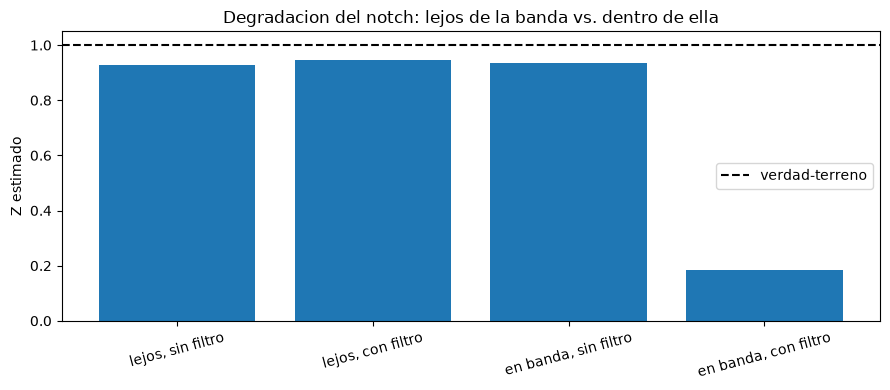

In [7]:
N_TRIALS_NOCLUTTER = 300
DEGRADATION_TOLERANCE_Z_FRAC = 0.20

# lejos de la banda: degradacion minima esperada
_, _, z_raw_far = summarize(0.0, V_SAFE_MPS, SIGMA_V_TEST, apply_filter=False, n_trials=N_TRIALS_NOCLUTTER)
_, _, z_filt_far = summarize(0.0, V_SAFE_MPS, SIGMA_V_TEST, apply_filter=True, n_trials=N_TRIALS_NOCLUTTER)
print(f"lejos de la banda: sin filtro Z={z_raw_far:.4f}  con filtro Z={z_filt_far:.4f}")
checks.append((f"lejos de la banda de notch, la degradacion de Z por el filtro es < {DEGRADATION_TOLERANCE_Z_FRAC:.0%}",
               abs(z_filt_far - z_raw_far) < DEGRADATION_TOLERANCE_Z_FRAC * POWER_WEATHER))

# dentro de la banda (v=0): limitacion conocida del notch, se mide y declara
_, _, z_raw_in = summarize(0.0, 0.0, SIGMA_V_TEST, apply_filter=False, n_trials=N_TRIALS_NOCLUTTER)
_, _, z_filt_in = summarize(0.0, 0.0, SIGMA_V_TEST, apply_filter=True, n_trials=N_TRIALS_NOCLUTTER)
loss_frac = (z_raw_in - z_filt_in) / z_raw_in
print(f"dentro de la banda (v=0): sin filtro Z={z_raw_in:.4f}  con filtro Z={z_filt_in:.4f}  "
      f"perdida={loss_frac:.0%}")
checks.append(("dentro de la banda de notch, el filtro pierde una fraccion medible de Z "
               "(limitacion conocida del notch, no oculta): > 20%", loss_frac > 0.20))

fig, ax = plt.subplots()
labels = ["lejos, sin filtro", "lejos, con filtro", "en banda, sin filtro", "en banda, con filtro"]
values = [z_raw_far, z_filt_far, z_raw_in, z_filt_in]
ax.bar(labels, values)
ax.axhline(POWER_WEATHER, color="black", linestyle="--", label="verdad-terreno")
ax.set_ylabel("Z estimado"); ax.set_title("Degradacion del notch: lejos de la banda vs. dentro de ella")
ax.legend()
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


## Fuera de alcance, declarado

- **Reconstrucción tipo GMAP dentro de cada subsecuencia** (interpolar la
  forma del espectro meteorológico en vez de poner a cero) — evitaría la
  pérdida medida en la Prueba 3 cuando la velocidad verdadera cae en la
  banda, al precio de mantener consistentes dos ajustes independientes
  antes de entrelazar. Mejora posterior explícita, no parte de este
  oráculo.
- **Interacción con polarimetría alternante** (mitad de muestras por
  canal): regla de rechazo de configuración, no una cantidad con
  verdad-terreno numérica propia — misma frontera que
  `dealiasing-de-rango.md` y `staggered_prt.ipynb`.
- **SZ(8/64) con código de fase sistemático**: página propia
  ([sz-second-trip-recovery.md](sz-second-trip-recovery.md)), diferida a
  Stage 2, no relacionada con este filtro pese al nombre compartido del
  autor.

In [8]:
all_ok = True
for name, ok in checks:
    print(f"[{'OK' if ok else 'FALLO'}] {name}")
    all_ok = all_ok and ok

assert all_ok, "el oraculo de filtrado de clutter en staggered-PRT no pasa todas las comprobaciones"
print("\nTodas las comprobaciones dentro de tolerancia.")


[OK] sin filtrar, el clutter sesga Z en mas del 50% (justifica el filtro)
[OK] filtrado SZ2000-notch recupera Z dentro del 25% de la verdad-terreno
[OK] filtrado SZ2000-notch recupera v1 dentro de 1.0 m/s de la verdad-terreno
[OK] filtrado SZ2000-notch recupera v2 dentro de 1.0 m/s de la verdad-terreno
[OK] v1 filtrado esta tan cerca de la verdad como el caso sin clutter (margen 2x)
[OK] v2 filtrado esta tan cerca de la verdad como el caso sin clutter (margen 2x)
[OK] Z se mantiene dentro de 25% y v1/v2 dentro de 1.0 m/s en todo el barrido de CSR (0-40 dB)
[OK] lejos de la banda de notch, la degradacion de Z por el filtro es < 20%
[OK] dentro de la banda de notch, el filtro pierde una fraccion medible de Z (limitacion conocida del notch, no oculta): > 20%

Todas las comprobaciones dentro de tolerancia.
